In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#Improve visualization
sns.set_style("whitegrid")

# Load Dataset

In [3]:
df = pd.read_csv(
    r"E:\End to end sales data project\Data\Sample - superstore.csv",
    encoding='ISO-8859-1'
)

In [4]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [5]:
#OVERVIEW

print("Dataset Overview")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Overview

Dataset Shape: (9994, 21)
Total Rows: 9,994
Total Columns: 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [6]:
#Column Information
print("Column Information")
print("="*60)

df.info()

Column Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   fl

In [7]:
print("Descriptive Staticstics")
print("="*60)

df.describe()

Descriptive Staticstics


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
#Missing Value Analysis
print("Missing Values Check")
print("="*60)

missing = df.isnull().sum()

missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct
})

missing_df = missing_df[missing_df["Missing_Count"] > 0]

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found")

Missing Values Check
No missing values found


In [9]:
#Duplicate Check
print("Duplicate Check")
print("="*60)

duplicates = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    
    print(f"\nRemoving {duplicates} duplicate rows...")
    
    df = df.drop_duplicates()
    
    print("Duplicates removed successfully.")
    print(f"New Dataset Shape: {df.shape}")
    
else:
    
    print("No duplicate rows found")

Duplicate Check
Total Duplicate Rows: 0
No duplicate rows found


In [10]:
#Data Type Conversion
print("Converting Date Columns")
print("="*60)

# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date columns successfully converted.\n")

print("Updated Data Types:")
print(df.dtypes)

Converting Date Columns
Date columns successfully converted.

Updated Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


# FEATURE ENGINEERING

In [11]:
print("Creating New Features")
print("="*60)

#Extract year & month from Order Date
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Month_Name"] = df["Order Date"].dt.strftime("%B")

#Quarter of order
df["Order_Quarter"] = df["Order Date"].dt.quarter

#Day of week
df["Order_Day"] = df["Order Date"].dt.day_name()

#Shipping duration
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

#Profit Margin
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

#Profitability flag
df["Is_Profitable"] = df["Profit"] > 0

print("New columns created successfully.\n")

print("New Dataset Shape:")
print(df.shape)

Creating New Features
New columns created successfully.

New Dataset Shape:
(9994, 29)


In [12]:
#Checking Data Quality

print("Checking Data Quality")
print("="*60)

# Negative quantity check
negative_qty = df[df["Quantity"] < 0]
print(f"Negative Quantity Records: {len(negative_qty)}")

# Negative sales check
negative_sales = df[df["Sales"] < 0]
print(f"Negative Sales Records: {len(negative_sales)}")

# Ship date before order date
wrong_dates = df[df["Ship Date"] < df["Order Date"]]
print(f"Ship Date before Order Date: {len(wrong_dates)}")

print("\nProfitability Summary")

print(f"Profitable Orders: {df['Is_Profitable'].sum():,}")
print(f"Loss Orders: {(~df['Is_Profitable']).sum():,}")

Checking Data Quality
Negative Quantity Records: 0
Negative Sales Records: 0
Ship Date before Order Date: 0

Profitability Summary
Profitable Orders: 8,058
Loss Orders: 1,936


In [13]:
#Save Cleaned Dataset
df.to_csv(
    r"E:\End to end sales data project\Data\Sample - superstore_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Exploratory Data Analysis

In [14]:
print(f"Dataset contains {df.shape[0]:,} records and {df.shape[1]} columns")

Dataset contains 9,994 records and 29 columns


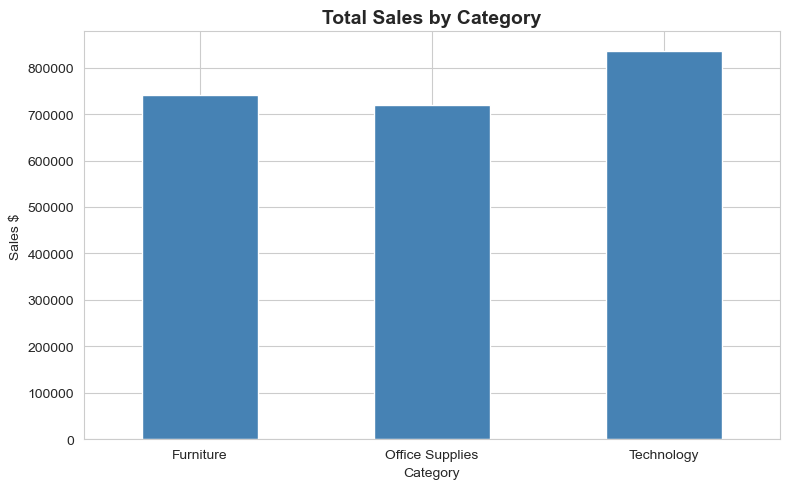

In [33]:
#Sales by Category

plt.figure(figsize=(8,5))

df.groupby('Category')['Sales'].sum().plot(
    kind='bar',
    color='steelblue'
)

plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Sales $')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

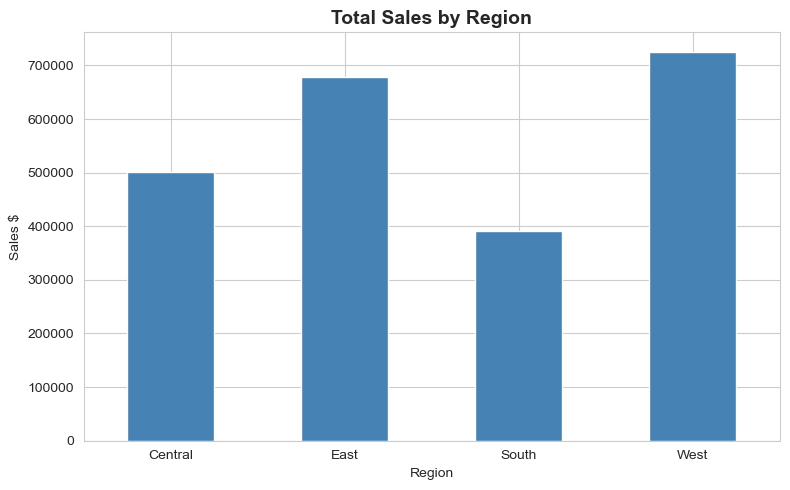

In [23]:
#Total Sales by Region

plt.figure(figsize=(8,5))

df.groupby('Region')['Sales'].sum().plot(
    kind='bar',
    color='steelblue'
)

plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Sales $')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_16796\456141597.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('Order Date').resample('M')['Sales'].sum()


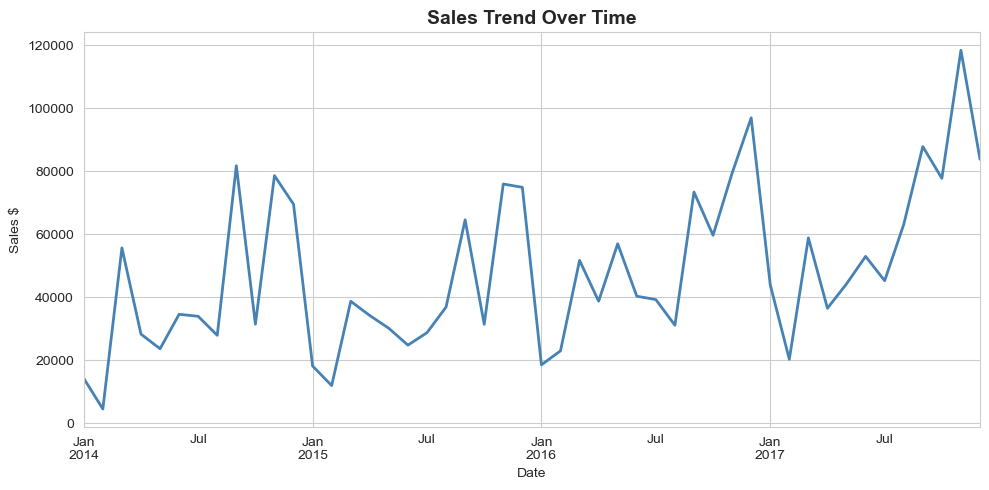

In [26]:
#Sales Trend Over Time

monthly_sales = df.set_index('Order Date').resample('M')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    color='steelblue',
    linewidth=2
)

plt.title('Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales $')

plt.tight_layout()
plt.show()

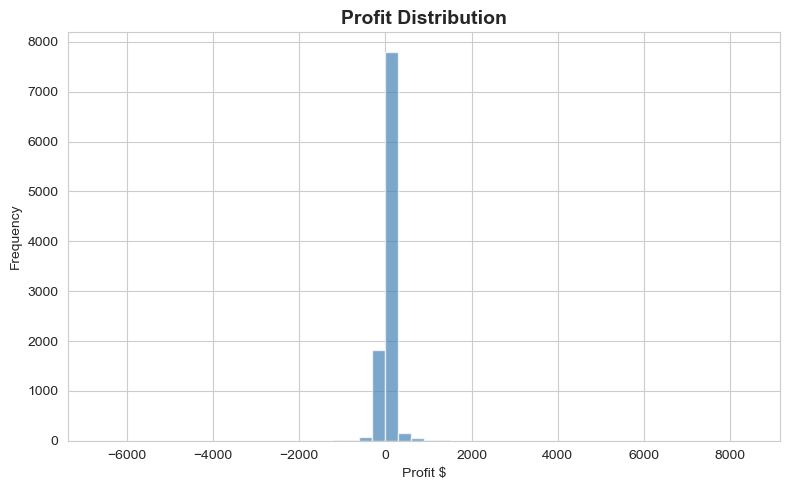

In [28]:
#Profit Distribution

plt.figure(figsize=(8,5))

df['Profit'].hist(
    bins=50,
    color='steelblue',
    alpha=0.7
)

plt.title('Profit Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Profit $')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


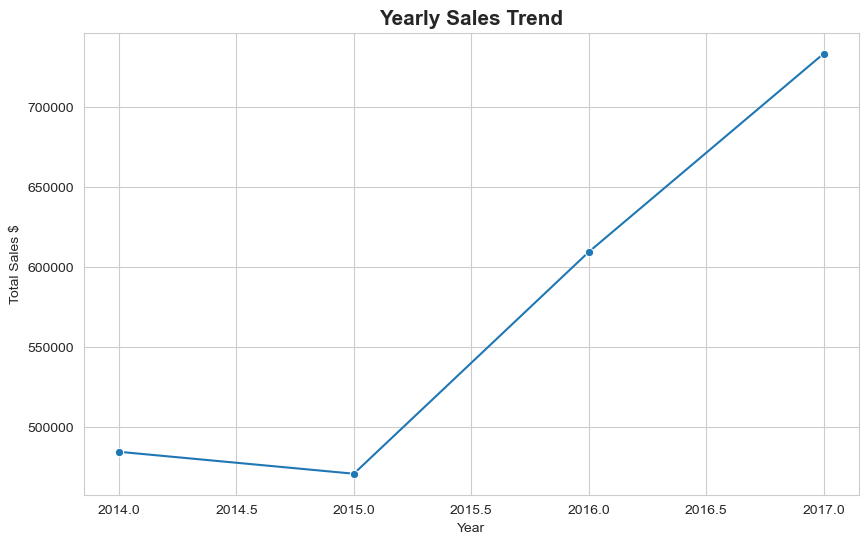

In [68]:
# Sales Trend by Year
yearly_sales = df.groupby('Order_Year')['Sales'].sum()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker='o'
)

plt.title("Yearly Sales Trend", fontsize=15, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Sales $")

plt.show()

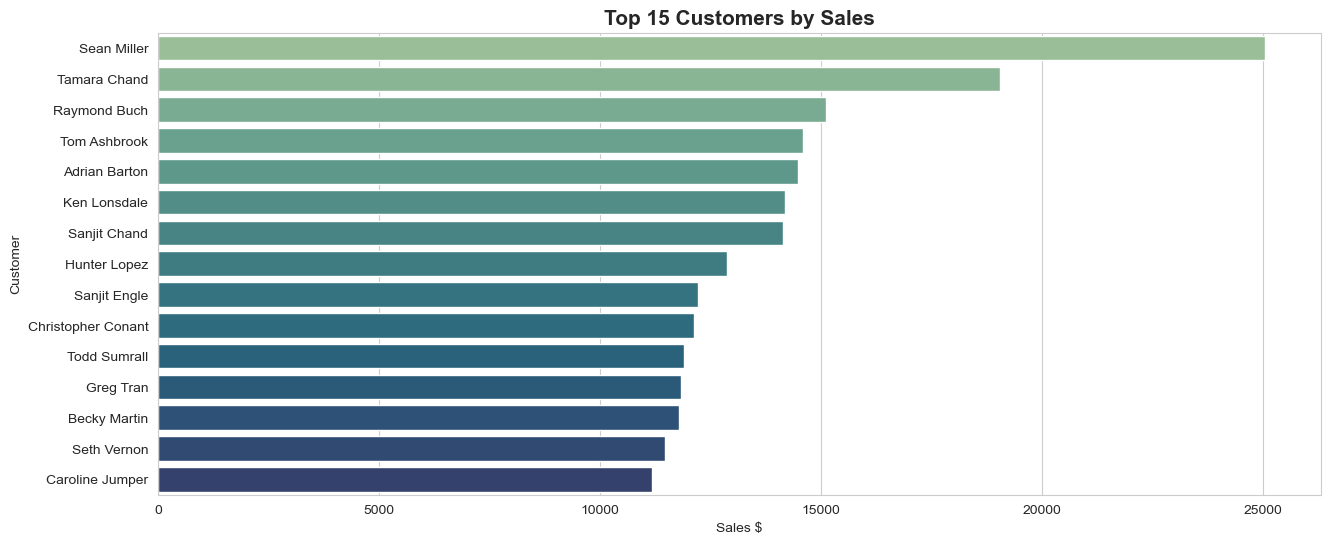

In [44]:
# Top 15 Customers by Sales

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(15,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette= 'crest'
)

plt.title("Top 15 Customers by Sales", fontsize=15, fontweight='bold')
plt.xlabel("Sales $")
plt.ylabel("Customer")

plt.show()

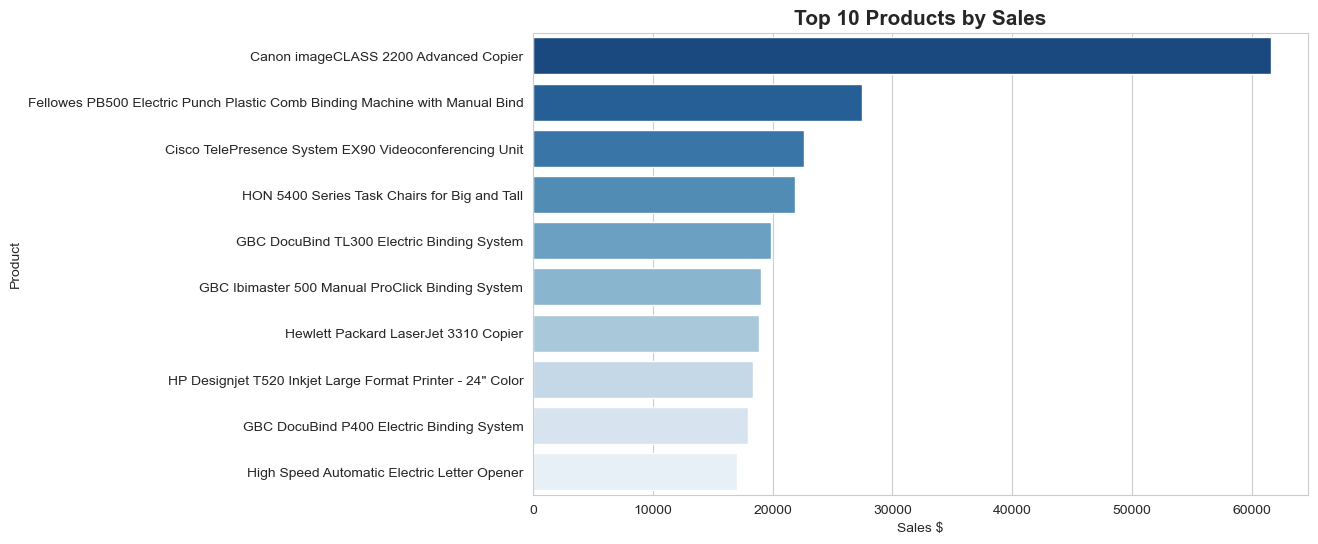

In [48]:
# Top 10 Products by Sales

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='Blues_r'
)

plt.title("Top 10 Products by Sales", fontsize=15, fontweight='bold')
plt.xlabel("Sales $")
plt.ylabel("Product")

plt.show()

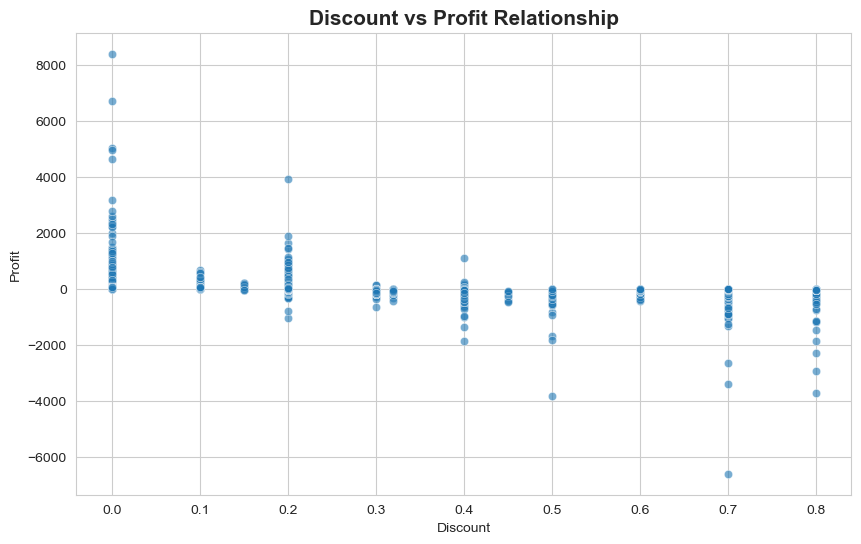

In [49]:
# Discount Vs Profit

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)

plt.title("Discount vs Profit Relationship", fontsize=15, fontweight='bold')

plt.show()

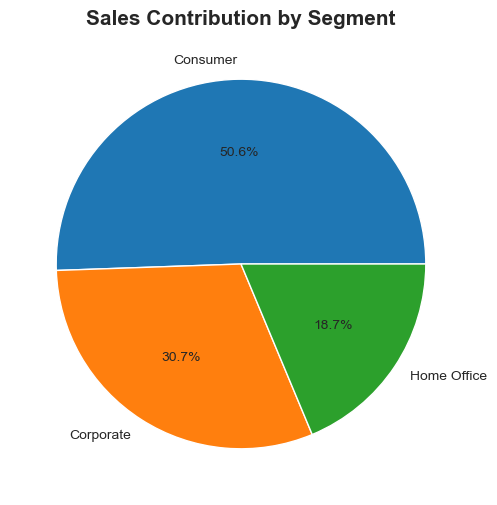

In [50]:
# Sales by Customer Segment

segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,6))

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sales Contribution by Segment", fontsize=15, fontweight='bold')
plt.ylabel("")

plt.show()

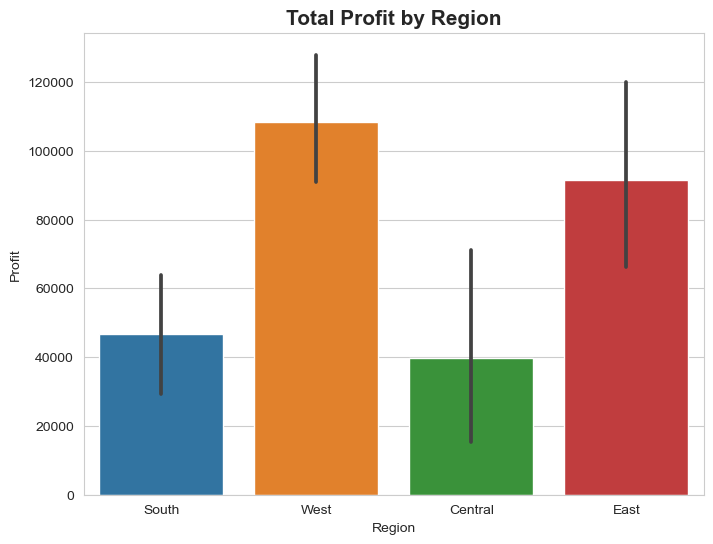

In [51]:
# Profit by Region

plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x='Region',
    y='Profit',
    estimator=sum
)

plt.title("Total Profit by Region", fontsize=15, fontweight='bold')

plt.show()

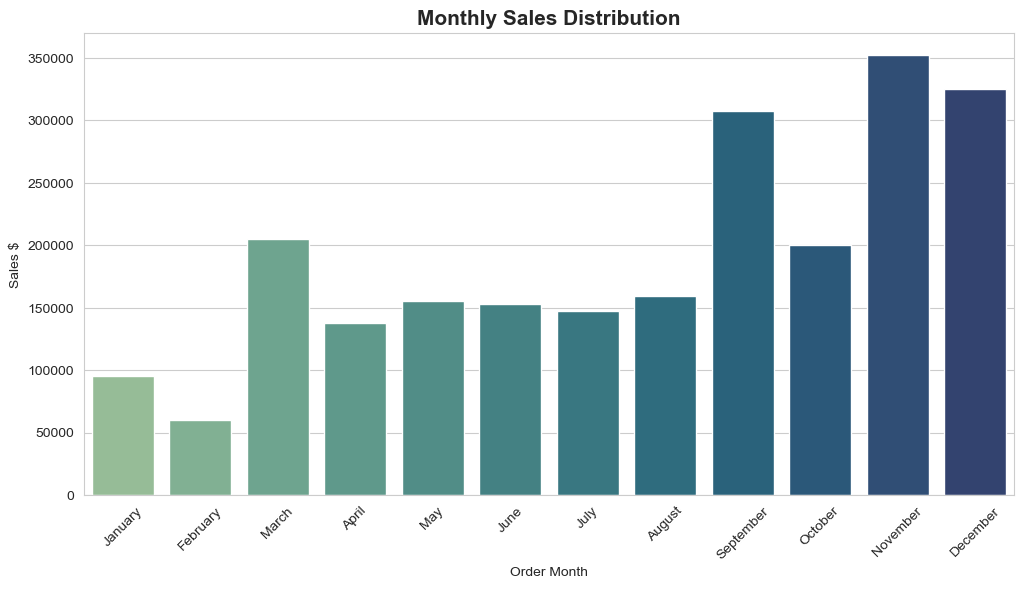

In [59]:
# Monthly Sales Distribution
monthly_sales = df.groupby('Order_Month_Name')['Sales'].sum()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    palette='crest'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Distribution", fontsize=15, fontweight='bold')
plt.ylabel("Sales $")
plt.xlabel("Order Month")


plt.show()

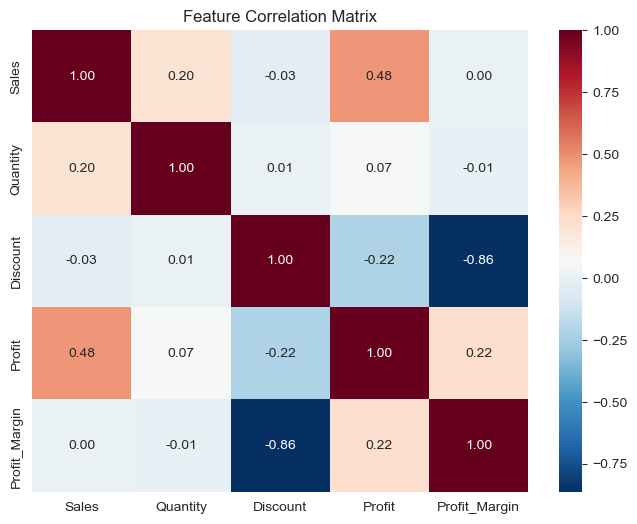

In [66]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df[['Sales','Quantity','Discount','Profit','Profit_Margin']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()